In [1]:
import itertools
import matplotlib.pyplot as plt
import numpy as np
import random
import pandas as pd
from scipy.stats import logistic, expon, nbinom, rv_discrete
import seaborn as sns

# Assignment 6
### Do Question 6, and three more questions of your choice.

### 1. Set review:

- Operations on sets (hints: sketch venn-type diagrams, and showing $A=B$ is the same as $A \subseteq B$ and $B \subseteq A$):
- $ (A \backslash B) \cup (A \cap B) = A $
- $ A \cup ( B \cap C) = (A \cup B) \cap (A \cup C)$
- $ A \backslash (B \cup C) = A\backslash B \cap A \backslash C $ and $A \backslash (B \cap C) = A \backslash B \cup A \backslash C$

- Plot the following sets: 
    - $A = \{x \in \mathbb{R}: x^2 -1 \ge 0 \}$ 
    - $B = \{ (x,y) \in \mathbb{R}^2: 3x -2y \ge 0 \}$
    - $C = \{ (x,y) \in \mathbb{R}^2: xy \ge 3 \}$
    - $D = \{ (x_1,x_2) \in \mathbb{R}^2: x_1 \ge 0, x_2 \ge 0, x_1 + x_2 \le 1 \}$
- The power set of $A$ is the set of all subsets of $A$, denoted $\mathcal{P}(A)$. What is the power set of $\{ 1, 2, 3 \}$? (Hint: The empty set is a subset of every set; the whole set is a subset of itself.)

### 2. Probability space basics:

- What are the outcomes for rolling a single, fair **THREE**-sided die? What's the set of all events? What are the probabilities of all the events?
- What about flipping a fair coin twice? (Hint: There are 4 outcomes, and $2^{4} = 16$ events.)
- What about rolling the **THREE**-sided die twice, and adding the results? Don't write down the set of all the possible events, but describe briefly what it looks like and how large it is. (Hint: There are 5 outcomes, and $2^{5}=32$ possible events.)

Obviously, a "three-sided die" doesn't exist, but this keeps you from spending a lot of time suffering in working out sets of events.

1. The outcomes for rolling a sigle fair three sided die is getting a 1,2,3 but all possible events are:
Outcome                     Probability
0                               0%
1                               1/3
2                               1/3
3                               1/3
1,2                             2/3
1,3                             2/3
1,2,3                           1


Flipping a Fair Coin Twice:
Outcome                     Probability
HH                              1/4
HT                              1/4
TT                              1/4
TH                              1/4



In the three sided dice method there are 5 possible outcomes, but many different ways that you could get those outcomes
With 4 being the most likely outcome as 4/9 events lead to 4 as the sum.





### 3. Random Variable Basics

- Imagine rolling a fair single six-sided die. There are 6 outcomes, all equally likely. Derive the sample space and the space of events. What are the probabilities of the outcomes and events? 
- Consider a random variable that assigns the square root of the number of pips on the die to each outcome. Write code to simulate rolling a single six-sided die and computing the value of the random variable. Simulate 5000 rolls and plot the mass function and ECDF of the random variable.
- Imagine rolling two fair six-sided die. Consider a random variable that adds up the pips on the dice. There are 11 outcomes (2 , 3, ..., 12), but not all are equally likely. Derive the sample space and **describe** the space of events. What are the probabilities of the outcomes?
- Write code to simulate the random variable (rolling two six-sided die and adding the results together). Simulate 10000 rolls and plot the mass function and ECDF.

numbers = list(range(37))
colors = []

for n in numbers:
    if n == 0:
        colors.append("green")
    elif (1 <= n <= 10) or (19 <= n <= 28):
        colors.append("red" if n % 2 == 1 else "black")
    else:  # 11–18 and 29–36
        colors.append("black" if n % 2 == 1 else "red")

roulette = pd.DataFrame({"number": numbers, "color": colors})
roulette.head(10)

### 4. Roulette

This question will be easiest if you read the whole thing, and come up with a clear plan for how you'll write the code.

Roulette is a betting game. There are 37 possible outcomes: A green 0, and the numbers 1 to 36 in red and black. Here is a picture of the (American, not Euro, it has an extra green 00) betting board:

![Roulette](./src/euro_roulette.jpg)

To bet, you must pay a dollar, but then you get payouts that depend on how many slots are in your bet
- Basic bets:
    - Red or Black slots
    - Odd or Even slots
    - A single slots, like 20
- More complex bets:
    - Split: Two adjacent slots (e.g. {1,2})
    - Square: Four adjacent slots (e.g. {1,2,4,5})
    - Street: Three slots in a row (e.g. {1,2,3})
    - Line: Six slots (e.g. {1,2,3,4,5,6})
In general, you can only bet on 1, 2, 3, 4, 6 slots, 12 slots, or 18 slots. If your bet occurs when the wheel is spun, you gain 36/K-1 where $K$ is the number of slots you bet on; if not, you lose a dollar and get -1.

- Write code to model spinning the roulette wheel, including the colors and numbers (you could make two lists of number and color and draw a random number between 0 and 37... or use a dataframe with color and number variables and sample it... or use a dict with key to number/color pairs...)
- Describe the probability space associated with the roulette wheel: Outcomes, events, probabilities (If there are 37 outcomes, there are $2^{37}= 137,438,953,472$ events, by the way)
- You wrote code to generate a spin of the roulette wheel. Now write a function that takes a basic or complex bet as an argument, and returns the result for the player (win or lose, and the payout 36/K-1 or -1)
- Simulate betting on red, betting on odd, betting on 7, a split, and a line 1000 times each.
- Compute the average values for the bets you just simulated. What are the expected average payoffs?

In [2]:
numbers = list(range(37))
colors = []

for n in numbers:
    if n == 0:
        colors.append("green")
    elif (1 <= n <= 10) or (19 <= n <= 28):
        colors.append("red" if n % 2 == 1 else "black")
    else:  
        colors.append("black" if n % 2 == 1 else "red")

roulette = pd.DataFrame({"number": numbers, "color": colors})
roulette.head(10)

,number,color
0,0,green
1,1,red
2,2,black
3,3,red
4,4,black
5,5,red
6,6,black
7,7,red
8,8,black
9,9,red


In [3]:
def spin_wheel():
    """Return one random outcome (number, color)."""
    result = roulette.sample(1).iloc[0]
    return result["number"], result["color"]

In [4]:
def roulette_bet(bet_numbers):
    """
    bet_numbers: list or set of numbers being bet on
    Returns: payout (float)
    """
    K = len(bet_numbers)
    result_num, _ = spin_wheel()
    if result_num in bet_numbers:
        return 36 / K - 1
    else:
        return -1

In [5]:

red_numbers = set(roulette[roulette["color"] == "red"]["number"])
odd_numbers = set(n for n in range(1, 37) if n % 2 == 1)
bet_on_7 = {7}


split_1_2 = {1, 2}
line_1_6 = {1, 2, 3, 4, 5, 6}

In [6]:
def simulate_bet(bet_numbers, n=1000):
    results = [roulette_bet(bet_numbers) for _ in range(n)]
    return np.mean(results)

n_sim = 1000
avg_red = simulate_bet(red_numbers, n_sim)
avg_odd = simulate_bet(odd_numbers, n_sim)
avg_7 = simulate_bet(bet_on_7, n_sim)
avg_split = simulate_bet(split_1_2, n_sim)
avg_line = simulate_bet(line_1_6, n_sim)

print(f"Average payoff betting on red:   {avg_red:.4f}")
print(f"Average payoff betting on odd:   {avg_odd:.4f}")
print(f"Average payoff betting on 7:     {avg_7:.4f}")
print(f"Average payoff split (1,2):      {avg_split:.4f}")
print(f"Average payoff line (1–6):       {avg_line:.4f}")

Average payoff betting on red:   -0.0200
Average payoff betting on odd:   -0.0560
Average payoff betting on 7:     -0.1720
Average payoff split (1,2):      0.1700
Average payoff line (1–6):       0.0740


Probability Space:

In total we know there are 37 total outcomes, as there is a green 0 and 18 red and 18 black. The events are a subset of the outcomes, which is equal to 2^37.
Since each spin of the roullete wheel gives every spot an equal chance of getting landed on betting on any single color/number combo gives you a 1/37 chance of being correct. your odds are higher if you bet on colors or split as opposed to betting on any one number.



### 5. CDF and PDF Basics

- Verify the following functions are distribution functions and compute their density functions. Plot the distribution and density.

1. $F(x) = \begin{cases}
0, & x \le 0 \\
\sqrt{x}, & 0 \le x \le 1 \\
1, & x \ge 1 
\end{cases}
$
2. $F(x) = \dfrac{1}{1+e^{-x}}$
3. For $ a < b < c$,
$
F(x) = \begin{cases}
0, & x \le 0 \\
\frac{(x-a)^2}{(b-a)(b-c)}, & a \le x \le c \\
1 - \frac{(b-x)^2}{(b-a)(b-c)}, & c < x < b \\
1, & x \ge b
\end{cases}
$
4. $ F(x) = \begin{cases}
0, & x <0 \\
1 - e^{-x}, & x>0
\end{cases}
$
5. $ F(x) = \begin{cases}
0, & x \le 0 \\
x, & 0 < x < 1\\
1, & x \ge 1
\end{cases}
$

In [7]:
x1 = np.linspace(0, 1, 500)
F1 = np.sqrt(x1)
f1 = 1/(2*np.sqrt(x1))
f1[0] = 0 
x2 = np.linspace(-6, 6, 500)
F2 = 1 / (1 + np.exp(-x2))
f2 = np.exp(-x2) / (1 + np.exp(-x2))**2


/var/folders/gr/5b74bfbs70x7jql3hkfyndmm0000gn/T/ipykernel_99482/694461951.py:3: RuntimeWarning: divide by zero encountered in divide
  f1 = 1/(2*np.sqrt(x1))


In [8]:
a, b, c = 0, 0.5, 1
x_left = np.linspace(a, b, 250)
x_right = np.linspace(b, c, 250)
F3 = np.concatenate([
    ((x_left - a)**2)/((b - a)*(c - a)),
    1 - ((c - x_right)**2)/((c - b)*(c - a))
])
f3 = np.concatenate([
    2*(x_left - a)/((b - a)*(c - a)),
    2*(c - x_right)/((c - b)*(c - a))
])
x3_tri = np.concatenate([x_left, x_right])


In [9]:
x4 = np.linspace(0, 8, 500)
F4 = 1 - np.exp(-x4)
f4 = np.exp(-x4)

In [10]:
x5 = np.linspace(0, 1, 500)
F5 = x5
f5 = np.ones_like(x5)

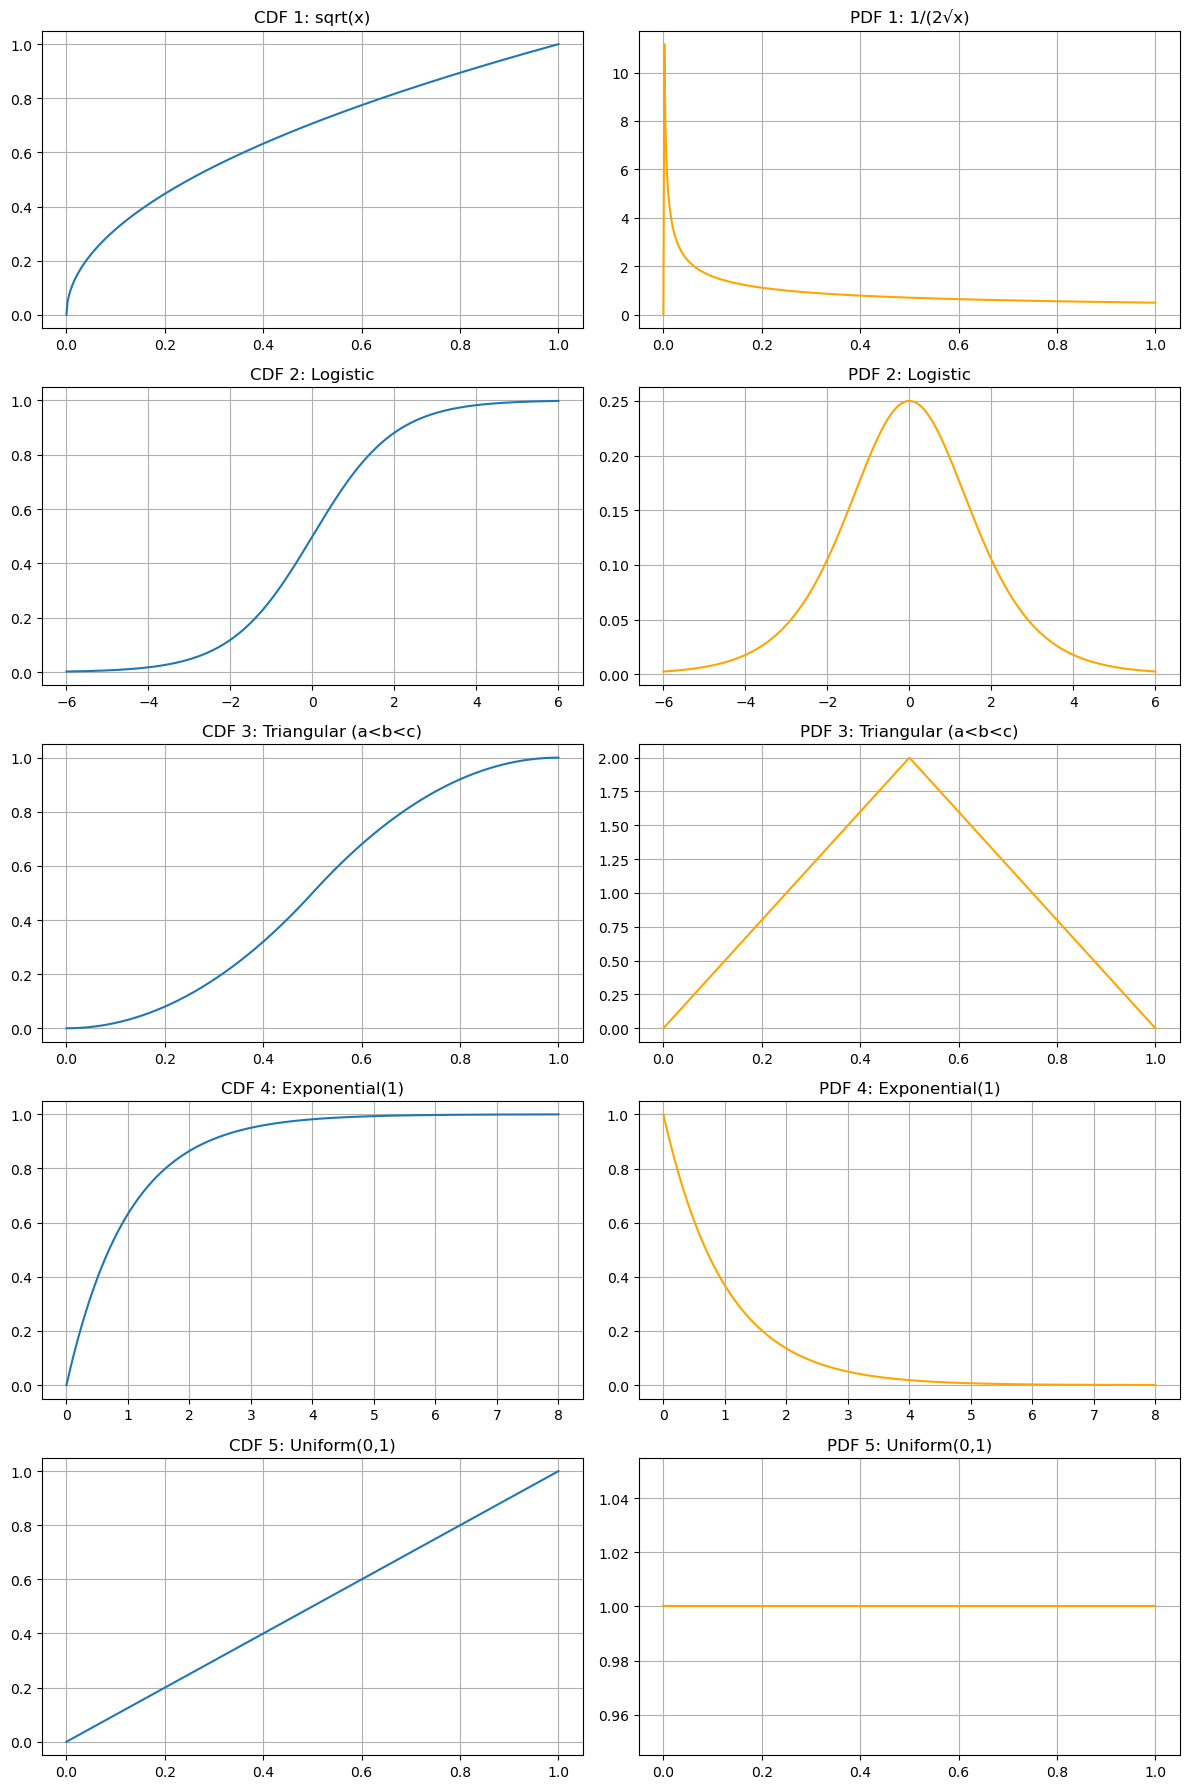

In [11]:
fig, axes = plt.subplots(5, 2, figsize=(12, 18))
axes = axes.flatten()

# 1. Root distribution
axes[0].plot(x1, F1)
axes[0].set_title('CDF 1: sqrt(x)')
axes[0].grid(True)
axes[1].plot(x1, f1, color='orange')
axes[1].set_title('PDF 1: 1/(2√x)')
axes[1].grid(True)

# 2. Logistic
axes[2].plot(x2, F2)
axes[2].set_title('CDF 2: Logistic')
axes[2].grid(True)
axes[3].plot(x2, f2, color='orange')
axes[3].set_title('PDF 2: Logistic')
axes[3].grid(True)

# 3. Triangular (a<b<c)
axes[4].plot(x3_tri, F3)
axes[4].set_title('CDF 3: Triangular (a<b<c)')
axes[4].grid(True)
axes[5].plot(x3_tri, f3, color='orange')
axes[5].set_title('PDF 3: Triangular (a<b<c)')
axes[5].grid(True)

# 4. Exponential
axes[6].plot(x4, F4)
axes[6].set_title('CDF 4: Exponential(1)')
axes[6].grid(True)
axes[7].plot(x4, f4, color='orange')
axes[7].set_title('PDF 4: Exponential(1)')
axes[7].grid(True)

# 5. Uniform(0,1)
axes[8].plot(x5, F5)
axes[8].set_title('CDF 5: Uniform(0,1)')
axes[8].grid(True)
axes[9].plot(x5, f5, color='orange')
axes[9].set_title('PDF 5: Uniform(0,1)')
axes[9].grid(True)

plt.tight_layout()
plt.show()

All five are appropriate CDF functions they all increase from 0 to 1 and are right continuous

### 6. Some Common Distributions

For the following distributions:
- Determine the support
- Compute the density from the distribution for the logistic and exponential distributions (take a derivative)
- Plot the density and distribution for a variety of parameter values
- Take a sample of 1000 draws $(x_1, x_2, ..., x_{1000})$ from the distribution, plot a KDE and ECDF, visually compare with the theoretical pdf/cdf
- Find an example of this general type of PDF/CDF from the Metabric cancer data

You can use https://docs.scipy.org/doc/scipy/reference/stats.html to generate values for the pdf/cdf and generate samples of random variates.


- Logistic distribution (similar to normal): 
$$
F(x; \sigma) = \dfrac{1}{1+e^{-x/\sigma}} 
$$
with $\sigma >0$.
- Exponential distribution (similar to log-normal):
$$
F_X(x) = \begin{cases}
0, & x<0 \\
1 - e^{-\lambda x}, & x \ge 0,
\end{cases}
$$
with $\lambda > 0$.
- Negative Binomial (similar to Poisson): The probability mass function for positive integers is:
$$
f(k;r,p) = \dfrac{(k+r-1)!}{k!(r-1)!}(1-p)^k p^r, \quad \text{ for $k=0,...n$}
$$
You can interpret this as follows: Flip a coin that comes up heads with probability $p$ until you get $r$ heads, and then stop. What is the probability of stopping at each $k=0,1,2,...$?
- Categorical (similar to Bernoulli): The probability mass function over $k = 1, 2, ..., K$ categories is
$$
f(k;p_1,...,p_K) = p_1^{k=1}p_2^{k=2}...p_K^{k=K}
$$
where $0 \le p_i \le 1$ and $ \sum_{k=1}^K p_k = 1$.


In [12]:
np.random.seed(42)

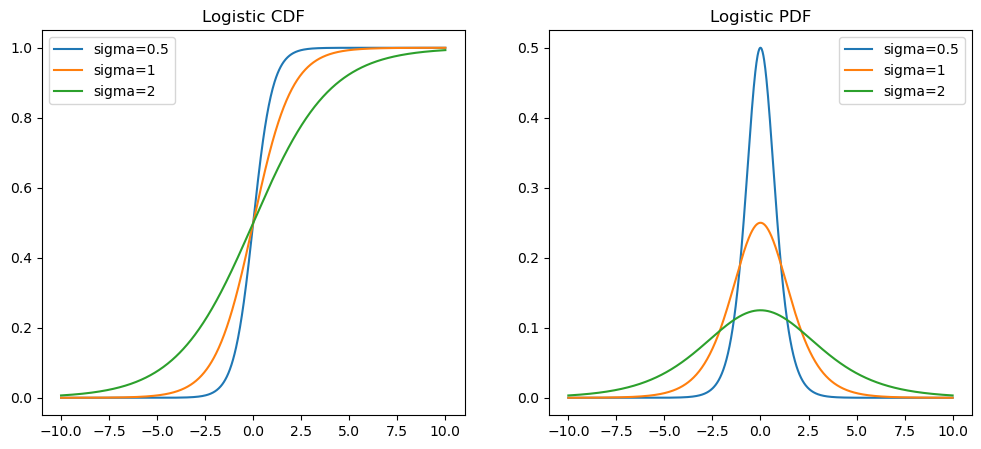

In [13]:
sigma_values = [0.5, 1, 2]  # example scale parameters

x = np.linspace(-10, 10, 1000)

plt.figure(figsize=(12, 5))
for sigma in sigma_values:
    # CDF
    F_x = logistic.cdf(x, loc=0, scale=sigma)
    # PDF (derivative of CDF)
    f_x = logistic.pdf(x, loc=0, scale=sigma)
    
    plt.subplot(1, 2, 1)
    plt.plot(x, F_x, label=f'sigma={sigma}')
    plt.title("Logistic CDF")
    
    plt.subplot(1, 2, 2)
    plt.plot(x, f_x, label=f'sigma={sigma}')
    plt.title("Logistic PDF")

plt.subplot(1, 2, 1)
plt.legend()
plt.subplot(1, 2, 2)
plt.legend()
plt.show()


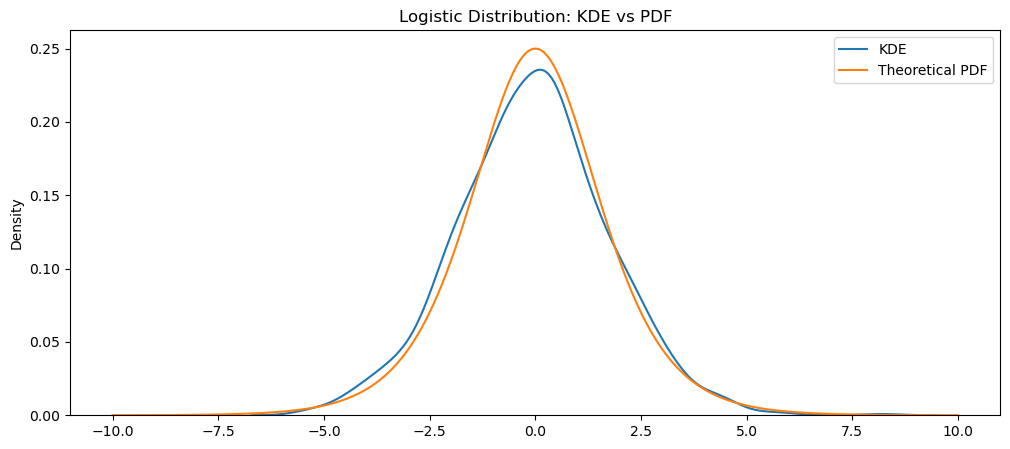

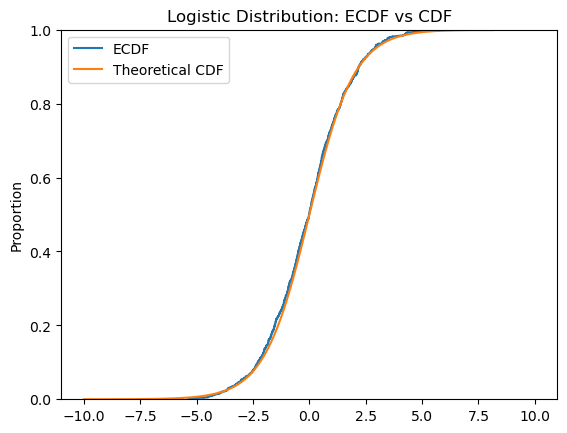

In [14]:
sigma = 1
samples = logistic.rvs(loc=0, scale=sigma, size=1000)

plt.figure(figsize=(12,5))
sns.kdeplot(samples, label="KDE")
plt.plot(x, logistic.pdf(x, loc=0, scale=sigma), label="Theoretical PDF")
plt.title("Logistic Distribution: KDE vs PDF")
plt.legend()
plt.show()

plt.figure()
sns.ecdfplot(samples, label="ECDF")
plt.plot(x, logistic.cdf(x, loc=0, scale=sigma), label="Theoretical CDF")
plt.title("Logistic Distribution: ECDF vs CDF")
plt.legend()
plt.show()

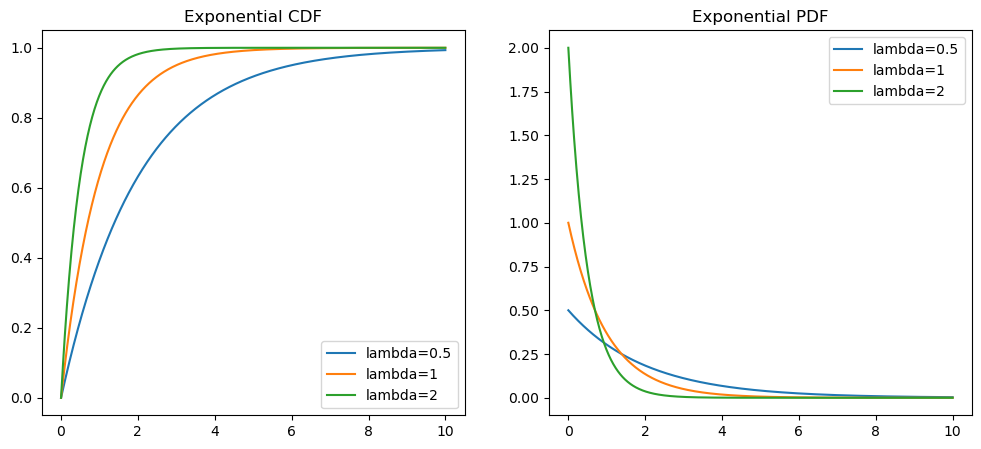

In [15]:
lambda_values = [0.5, 1, 2]
x = np.linspace(0, 10, 1000)

plt.figure(figsize=(12,5))
for lam in lambda_values:
    F_x = expon.cdf(x, scale=1/lam)
    f_x = expon.pdf(x, scale=1/lam)
    
    plt.subplot(1, 2, 1)
    plt.plot(x, F_x, label=f'lambda={lam}')
    plt.title("Exponential CDF")
    
    plt.subplot(1, 2, 2)
    plt.plot(x, f_x, label=f'lambda={lam}')
    plt.title("Exponential PDF")

plt.subplot(1, 2, 1)
plt.legend()
plt.subplot(1, 2, 2)
plt.legend()
plt.show()


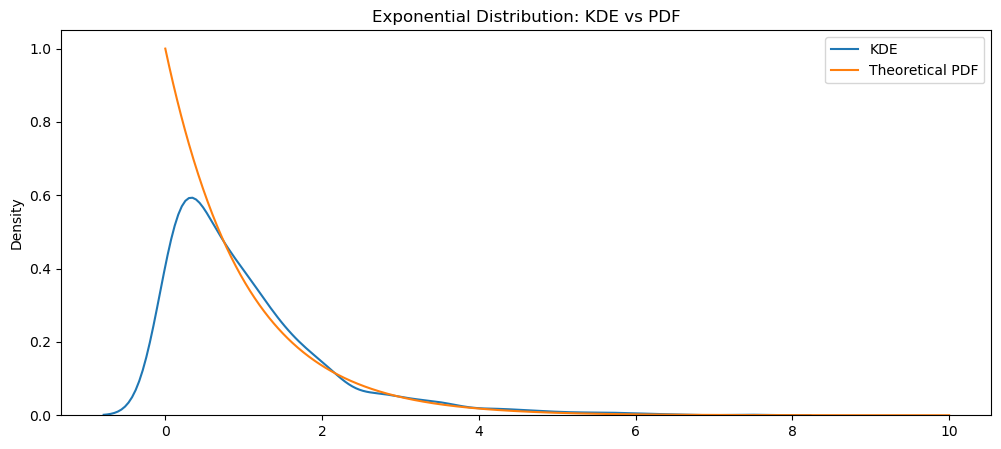

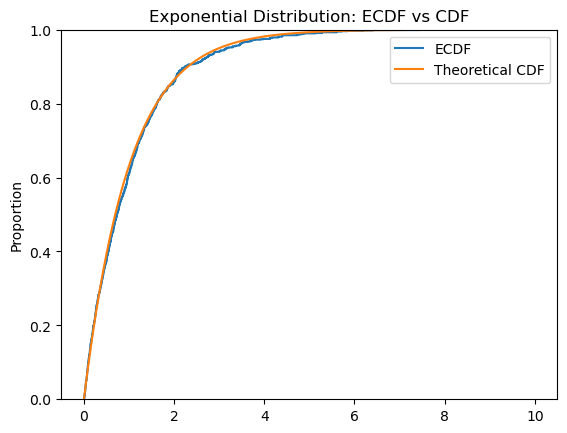

In [16]:
lam = 1
samples = expon.rvs(scale=1/lam, size=1000)

plt.figure(figsize=(12,5))
sns.kdeplot(samples, label="KDE")
plt.plot(x, expon.pdf(x, scale=1/lam), label="Theoretical PDF")
plt.title("Exponential Distribution: KDE vs PDF")
plt.legend()
plt.show()

plt.figure()
sns.ecdfplot(samples, label="ECDF")
plt.plot(x, expon.cdf(x, scale=1/lam), label="Theoretical CDF")
plt.title("Exponential Distribution: ECDF vs CDF")
plt.legend()
plt.show()

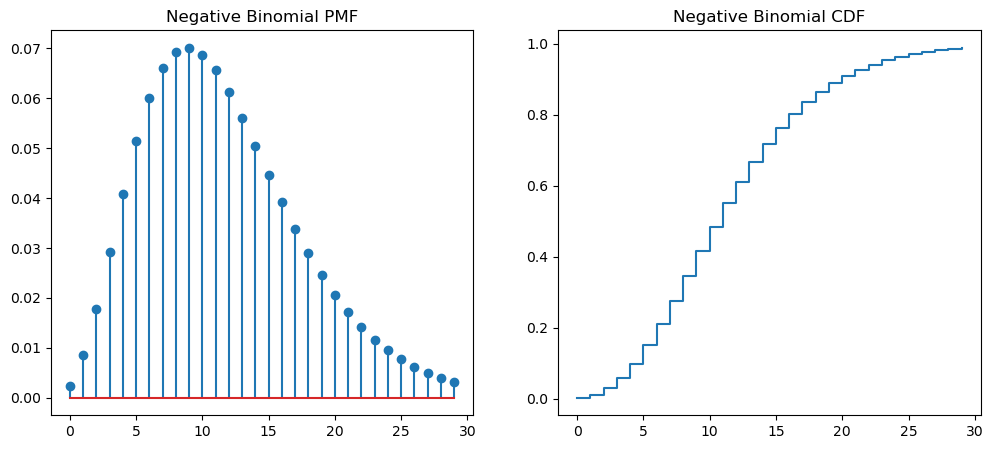

In [17]:
r, p = 5, 0.3  # number of successes, success probability
k = np.arange(0, 30)
pmf = nbinom.pmf(k, n=r, p=p)
cdf = nbinom.cdf(k, n=r, p=p)

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.stem(k, pmf)  # removed use_line_collection
plt.title("Negative Binomial PMF")

plt.subplot(1, 2, 2)
plt.step(k, cdf, where="post")
plt.title("Negative Binomial CDF")
plt.show()

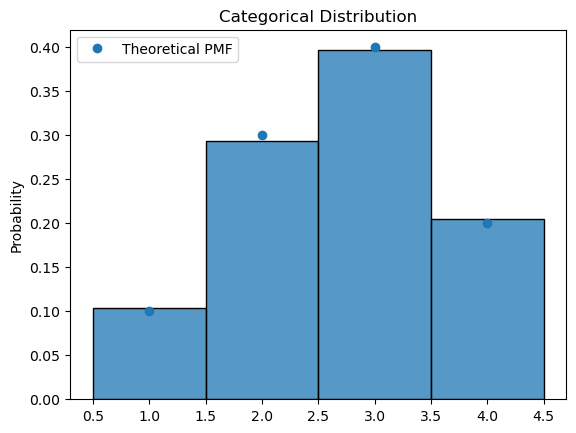

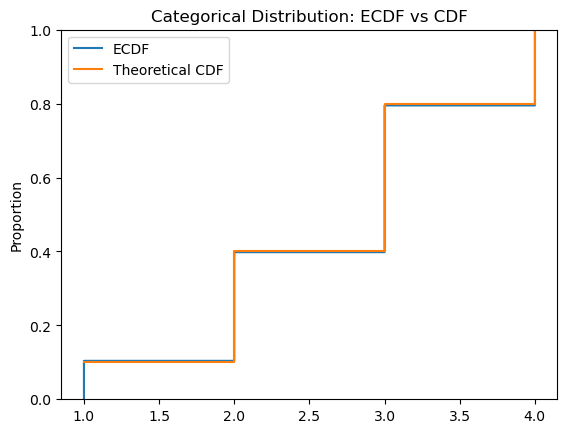

In [18]:
p = [0.1, 0.3, 0.4, 0.2]
k = np.arange(1, len(p)+1)
categorical_rv = rv_discrete(values=(k, p))

# Sample and plot
samples = categorical_rv.rvs(size=1000)
plt.figure()
sns.histplot(samples, bins=np.arange(1,6)-0.5, stat="probability")
plt.plot(k, p, 'o', label="Theoretical PMF")
plt.title("Categorical Distribution")
plt.legend()
plt.show()

plt.figure()
sns.ecdfplot(samples, label="ECDF")
plt.step(k, np.cumsum(p), where="post", label="Theoretical CDF")
plt.title("Categorical Distribution: ECDF vs CDF")
plt.legend()
plt.show()

In [19]:
metabric = pd.read_csv("data/metabric.csv")

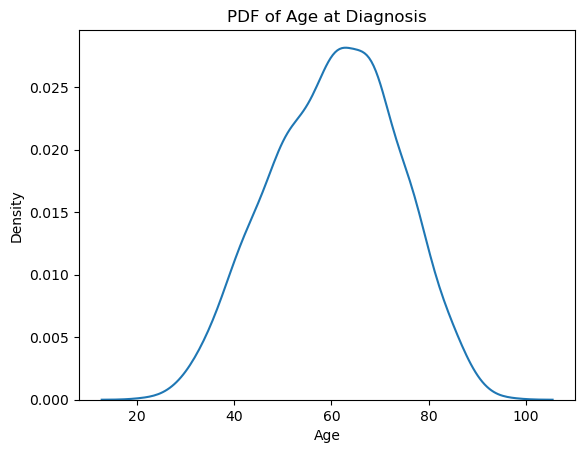

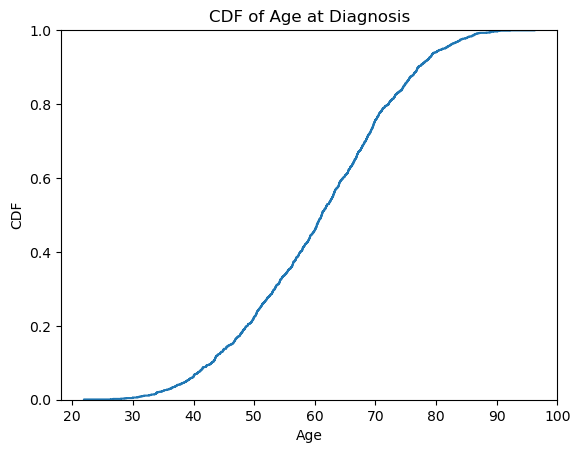

In [20]:
age = metabric['Age at Diagnosis'].dropna()

# PDF using KDE
sns.kdeplot(age)
plt.title("PDF of Age at Diagnosis")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

# CDF using ECDF
sns.ecdfplot(age)
plt.title("CDF of Age at Diagnosis")
plt.xlabel("Age")
plt.ylabel("CDF")
plt.show()

Code was written with the assistance of ChatGPT